<a href="https://colab.research.google.com/github/Raus29han/ML-Projects/blob/main/Crop_Disease_Detection_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ============================================
# CROP DISEASE DETECTION
# Project Setup
# ============================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import json

print("TensorFlow version:", tf.__version__)

print("GPU devices:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
# Check required libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("All basic libraries loaded successfully.")

All basic libraries loaded successfully.


In [10]:
import tensorflow as tf
import tensorflow_datasets as tfds
import google.protobuf

print("TensorFlow:", tf.__version__)
print("TFDS loaded:", hasattr(tfds, "load"))
print("Protobuf:", google.protobuf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
TFDS loaded: False
Protobuf: 5.29.6
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
!pip install -U "protobuf>=6.31.1" tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.


In [12]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 14.4 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5


In [13]:
from datasets import load_dataset

dataset = load_dataset(
    "geraldmc/plantvillage-full",
    revision="v0.1.0"
)

print(dataset)

README.md:   0%|          | 0.00/549 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  402MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  453MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/54304 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
        num_rows: 54304
    })
})


In [14]:
print(dataset["train"].features)

{'image': Image(mode=None, decode=True), 'class_label': Value('string'), 'class_idx': Value('int32'), 'host': Value('string'), 'disease': Value('string'), 'split': Value('string'), 'leaf_id': Value('string'), 'leaf_grouped': Value('bool')}


In [15]:
print(dataset["train"][0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7E6E4A692F90>, 'class_label': 'Apple___Apple_scab', 'class_idx': 0, 'host': 'Apple', 'disease': 'Apple scab', 'split': 'test', 'leaf_id': 'Apple___Apple_scab::leaf_79', 'leaf_grouped': True}


In [16]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
        num_rows: 54304
    })
})


In [17]:
print(dataset["train"].features)

{'image': Image(mode=None, decode=True), 'class_label': Value('string'), 'class_idx': Value('int32'), 'host': Value('string'), 'disease': Value('string'), 'split': Value('string'), 'leaf_id': Value('string'), 'leaf_grouped': Value('bool')}


In [18]:
from collections import Counter

labels = dataset["train"]["class_label"]

unique_labels = sorted(set(labels))

print("Number of classes:", len(unique_labels))

print("\nClasses:")
for i, label in enumerate(unique_labels):
    print(i, "->", label)

Number of classes: 38

Classes:
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy
5 -> Cherry_(including_sour)___Powdery_mildew
6 -> Cherry_(including_sour)___healthy
7 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 -> Corn_(maize)___Common_rust_
9 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
30 -> Tomato___Late_blight
31 -> T

In [19]:
sample = dataset["train"][0]

print("Image:", sample["image"])
print("Class label:", sample["class_label"])
print("Class index:", sample["class_idx"])
print("Host:", sample["host"])
print("Disease:", sample["disease"])

Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7E6E3ADC8410>
Class label: Apple___Apple_scab
Class index: 0
Host: Apple
Disease: Apple scab


Class: Apple___Apple_scab
Crop: Apple
Disease: Apple scab
Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7E6E3ADC8690>


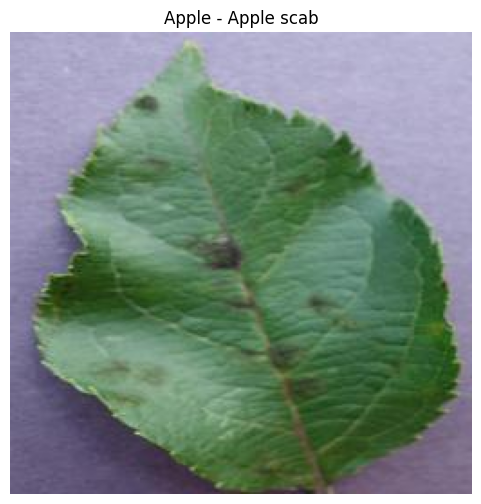

In [20]:
import matplotlib.pyplot as plt

sample = dataset["train"][0]

print("Class:", sample["class_label"])
print("Crop:", sample["host"])
print("Disease:", sample["disease"])
print("Image:", sample["image"])

plt.figure(figsize=(6, 6))
plt.imshow(sample["image"])
plt.axis("off")
plt.title(f"{sample['host']} - {sample['disease']}")
plt.show()

In [21]:
from collections import Counter

print(Counter(dataset["train"]["split"]))

Counter({'train': 43356, 'test': 10948})


In [22]:
import numpy as np

# Get all class labels
class_names = sorted(set(dataset["train"]["class_label"]))

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

for i, name in enumerate(class_names):
    print(i, "->", name)

Number of classes: 38
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy
5 -> Cherry_(including_sour)___Powdery_mildew
6 -> Cherry_(including_sour)___healthy
7 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 -> Corn_(maize)___Common_rust_
9 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
30 -> Tomato___Late_blight
31 -> Tomato___Le

In [23]:
class_to_index = {
    name: i for i, name in enumerate(class_names)
}

print(class_to_index)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

In [24]:
def add_numeric_label(example):
    example["label"] = class_to_index[example["class_label"]]
    return example

dataset = dataset.map(
    add_numeric_label
)

print(dataset["train"][0]["label"])

Map:   0%|          | 0/54304 [00:00<?, ? examples/s]

0


In [25]:
split_dataset = dataset["train"].train_test_split(
    test_size=0.20,
    seed=42
)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 43443
Validation images: 10861


In [26]:
TRAIN_SIZE = 20000
VAL_SIZE = 4000

train_dataset = train_dataset.shuffle(
    seed=42
).select(range(TRAIN_SIZE))

val_dataset = val_dataset.shuffle(
    seed=42
).select(range(VAL_SIZE))

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))

Training: 20000
Validation: 4000


In [27]:
IMG_SIZE = 224

def preprocess(example):
    image = example["image"].convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))

    image = np.array(image, dtype=np.float32)

    return {
        "pixel_values": image,
        "label": example["label"]
    }

In [28]:
train_processed = train_dataset.map(
    preprocess,
    remove_columns=train_dataset.column_names
)

val_processed = val_dataset.map(
    preprocess,
    remove_columns=val_dataset.column_names
)

print(train_processed)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'pixel_values'],
    num_rows: 20000
})


In [29]:
import tensorflow as tf

def create_tf_dataset(hf_dataset):
    images = np.array(
        hf_dataset["pixel_values"],
        dtype=np.float32
    )

    labels = np.array(
        hf_dataset["label"],
        dtype=np.int32
    )

    return tf.data.Dataset.from_tensor_slices(
        (images, labels)
    )

In [30]:
import tensorflow as tf
import numpy as np

IMG_SIZE = 224
BATCH_SIZE = 32

def generator(dataset):
    for example in dataset:
        image = np.array(
            example["pixel_values"],
            dtype=np.float32
        )
        label = np.int32(example["label"])

        yield image, label


train_tf = tf.data.Dataset.from_generator(
    lambda: generator(train_processed),
    output_signature=(
        tf.TensorSpec(
            shape=(224, 224, 3),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(),
            dtype=tf.int32
        )
    )
)

val_tf = tf.data.Dataset.from_generator(
    lambda: generator(val_processed),
    output_signature=(
        tf.TensorSpec(
            shape=(224, 224, 3),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(),
            dtype=tf.int32
        )
    )
)

In [31]:
train_tf = (
    train_tf
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_tf = (
    val_tf
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("TensorFlow datasets ready!")

TensorFlow datasets ready!


In [32]:
train_dataset
val_dataset

Dataset({
    features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped', 'label'],
    num_rows: 4000
})

In [33]:
split_dataset = dataset["train"].train_test_split(
    test_size=0.20,
    seed=42
)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 43443
Validation images: 10861


In [34]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [36]:
import tensorflow as tf
import numpy as np

IMG_SIZE = 224
BATCH_SIZE = 32

def image_generator(hf_dataset):
    for example in hf_dataset:
        image = example["image"].convert("RGB")
        image = image.resize((IMG_SIZE, IMG_SIZE))

        image = np.array(image, dtype=np.float32)
        label = np.int32(example["label"])

        yield image, label


output_signature = (
    tf.TensorSpec(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        dtype=tf.float32
    ),
    tf.TensorSpec(
        shape=(),
        dtype=tf.int32
    )
)

train_tf = tf.data.Dataset.from_generator(
    lambda: image_generator(train_dataset),
    output_signature=output_signature
)

val_tf = tf.data.Dataset.from_generator(
    lambda: image_generator(val_dataset),
    output_signature=output_signature
)

train_tf = (
    train_tf
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_tf = (
    val_tf
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training pipeline ready!")

Training pipeline ready!


In [37]:
images, labels = next(iter(train_tf))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: (32, 224, 224, 3)
Labels: (32,)


In [38]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small

NUM_CLASSES = len(class_names)

# Load pretrained MobileNetV3
base_model = MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True
)

# Freeze pretrained layers
base_model.trainable = False

# Build model
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Pretrained CNN
    base_model,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        21,926 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961,046 (3.67 MB)

 Trainable params: 21,926 (85.65 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [39]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [40]:
print("Number of classes:", NUM_CLASSES)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Number of classes: 38
Training samples: 43443
Validation samples: 10861


In [41]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "best_crop_disease_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stopping,
    reduce_lr
]

print("Callbacks ready.")

Callbacks ready.


In [42]:
EPOCHS = 5

history = model.fit(
    train_tf,
    validation_data=val_tf,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
   1358/Unknown 170s 114ms/step - accuracy: 0.6302 - loss: 1.4448

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.90286, saving model to best_crop_disease_model.keras

Epoch 1: finished saving model to best_crop_disease_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 211s 143ms/step - accuracy: 0.7835 - loss: 0.8284 - val_accuracy: 0.9029 - val_loss: 0.3329 - learning_rate: 0.0010
Epoch 2/5
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8997 - loss: 0.3619
Epoch 2: val_accuracy improved from 0.90286 to 0.92413, saving model to best_crop_disease_model.keras

Epoch 2: finished saving model to best_crop_disease_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 192s 136ms/step - accuracy: 0.9034 - loss: 0.3386 - val_accuracy: 0.9241 - val_loss: 0.2513 - learning_rate: 0.0010
Epoch 3/5
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9167 - loss: 0.2791
Epoch 3: val_accuracy improved from 0.92413 to 0.92947, saving model to best_crop_disease_model.keras

Epoch 3: finished saving model to best_crop_disease_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━

In [43]:
train_tf = train_tf.repeat()
val_tf = val_tf.repeat()

STEPS_PER_EPOCH = len(train_dataset) // BATCH_SIZE
VALIDATION_STEPS = len(val_dataset) // BATCH_SIZE

print("Steps per epoch:", STEPS_PER_EPOCH)
print("Validation steps:", VALIDATION_STEPS)

Steps per epoch: 1357
Validation steps: 339


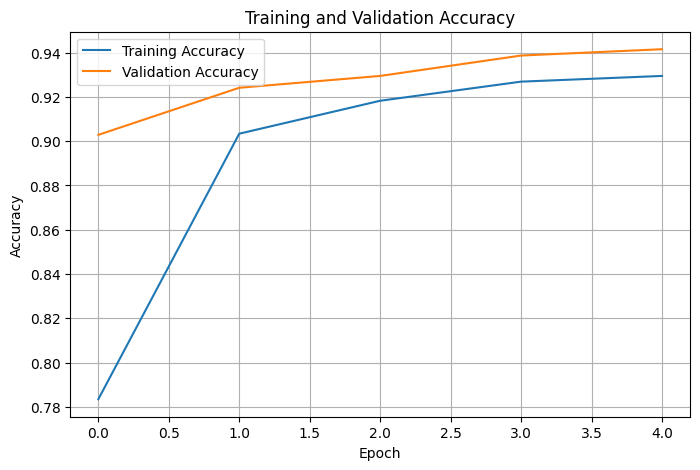

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

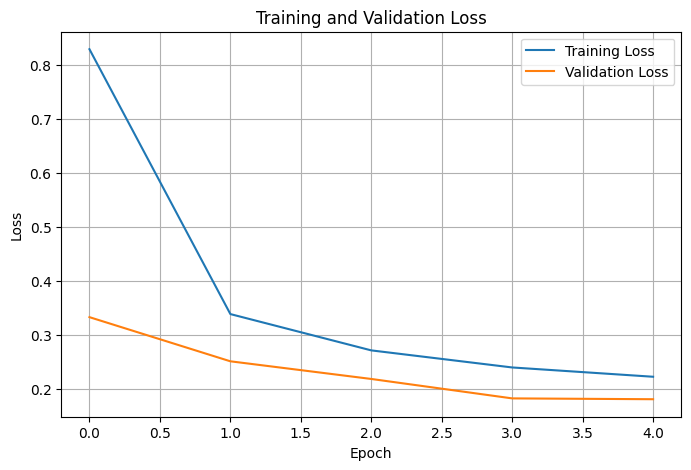

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [46]:
# Unfreeze the MobileNetV3 base
base_model.trainable = True

# Freeze the earlier layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep Batch Normalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Recompile with a very small learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model...")

Fine-tuning model...


In [47]:
trainable_count = sum(
    1 for layer in model.layers if layer.trainable
)

print("Trainable top-level layers:", trainable_count)

Trainable top-level layers: 7


In [48]:
trainable_base = sum(
    1 for layer in base_model.layers if layer.trainable
)

print("Trainable MobileNetV3 layers:", trainable_base)

Trainable MobileNetV3 layers: 24


In [49]:
FINE_TUNE_EPOCHS = 5

history_finetune = model.fit(
    train_tf,
    validation_data=val_tf,
    epochs=FINE_TUNE_EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks
)

Epoch 1/5
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9401 - loss: 0.1913
Epoch 1: val_accuracy improved from 0.94153 to 0.95271, saving model to best_crop_disease_model.keras

Epoch 1: finished saving model to best_crop_disease_model.keras
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 211s 146ms/step - accuracy: 0.9426 - loss: 0.1807 - val_accuracy: 0.9527 - val_loss: 0.1477 - learning_rate: 1.0000e-05
Epoch 2/5
1356/1357 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9511 - loss: 0.1536
Epoch 2: val_accuracy improved from 0.95271 to 0.95446, saving model to best_crop_disease_model.keras

Epoch 2: finished saving model to best_crop_disease_model.keras
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 197s 145ms/step - accuracy: 0.9505 - loss: 0.1540 - val_accuracy: 0.9545 - val_loss: 0.1400 - learning_rate: 1.0000e-05
Epoch 3/5
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9538 - loss: 0.1428
Epoch 3: val_accuracy improved from 0.95446 to 0.95612, saving model to best_crop_disease_model.k

In [50]:
# Evaluate the best saved model
best_model = tf.keras.models.load_model(
    "best_crop_disease_model.keras"
)

results = best_model.evaluate(
    val_tf,
    steps=VALIDATION_STEPS,
    verbose=1
)

print("Validation Loss:", results[0])
print("Validation Accuracy:", results[1])

339/339 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - accuracy: 0.9609 - loss: 0.1212
Validation Loss: 0.1211986169219017
Validation Accuracy: 0.9609144330024719


In [51]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print("Class names saved!")
print("Number of classes:", len(class_names))

Class names saved!
Number of classes: 38


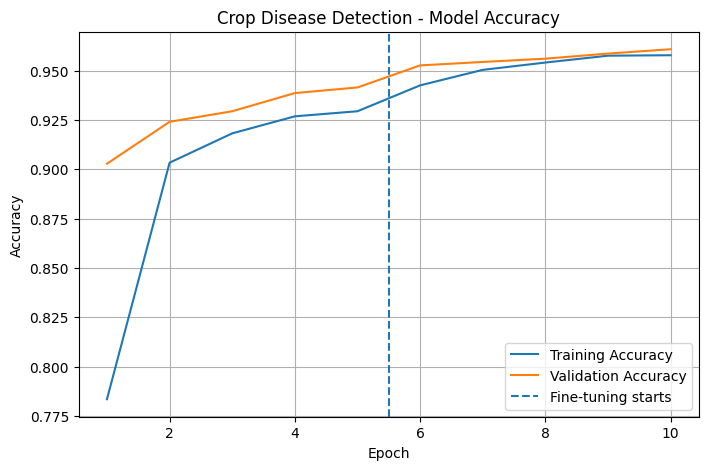

In [52]:
import matplotlib.pyplot as plt

# Combine the two training histories
acc = history.history["accuracy"] + history_finetune.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_finetune.history["val_accuracy"]

loss = history.history["loss"] + history_finetune.history["loss"]
val_loss = history.history["val_loss"] + history_finetune.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.axvline(
    x=len(history.history["accuracy"]) + 0.5,
    linestyle="--",
    label="Fine-tuning starts"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Crop Disease Detection - Model Accuracy")
plt.legend()
plt.grid()
plt.show()

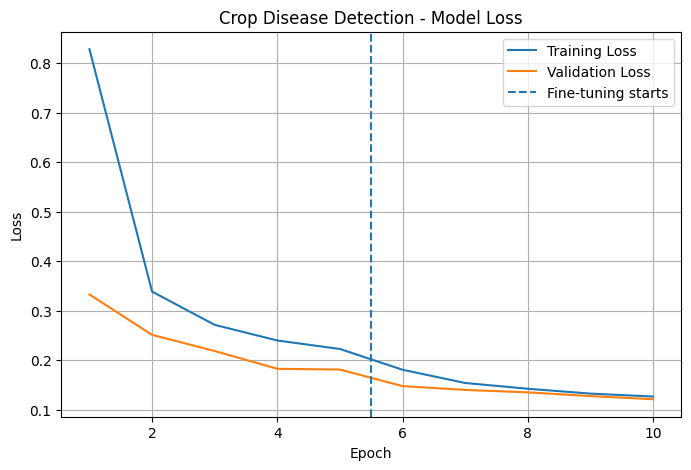

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.axvline(
    x=len(history.history["loss"]) + 0.5,
    linestyle="--",
    label="Fine-tuning starts"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Crop Disease Detection - Model Loss")
plt.legend()
plt.grid()
plt.show()


In [54]:
from google.colab import files
from PIL import Image
import numpy as np
import tensorflow as tf

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")
image = image.resize((224, 224))

image_array = np.array(image, dtype=np.float32)
image_array = np.expand_dims(image_array, axis=0)

print("Image shape:", image_array.shape)

Saving high-resolution-image-of-a-single-green-leaf-isolated-on-a-transparent-background-showcasing-detailed-veins-and-natural-texture-perfect-for-design-use-png.webp to high-resolution-image-of-a-single-green-leaf-isolated-on-a-transparent-background-showcasing-detailed-veins-and-natural-texture-perfect-for-design-use-png.webp
Image shape: (1, 224, 224, 3)


In [55]:
predictions = best_model.predict(image_array, verbose=0)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

Predicted class: Blueberry___healthy
Confidence: 98.86%


In [56]:
top_5_indices = np.argsort(predictions[0])[-5:][::-1]

print("\nTop 5 Predictions:")
print("-" * 50)

for rank, index in enumerate(top_5_indices, start=1):
    print(
        f"{rank}. {class_names[index]} "
        f"→ {predictions[0][index] * 100:.2f}%"
    )


Top 5 Predictions:
--------------------------------------------------
1. Blueberry___healthy → 98.86%
2. Soybean___healthy → 1.07%
3. Corn_(maize)___Common_rust_ → 0.04%
4. Strawberry___healthy → 0.01%
5. Corn_(maize)___healthy → 0.00%


In [57]:
from PIL import Image
import numpy as np

def predict_disease(image):
    # Convert to RGB
    image = image.convert("RGB")

    # Resize
    image = image.resize((224, 224))

    # Convert to NumPy
    image_array = np.array(image, dtype=np.float32)

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    predictions = best_model.predict(
        image_array,
        verbose=0
    )[0]

    # Get top prediction
    predicted_index = np.argmax(predictions)

    predicted_class = class_names[predicted_index]
    confidence = float(predictions[predicted_index])

    # Top 5
    top_indices = np.argsort(predictions)[-5:][::-1]

    top_predictions = {
        class_names[i]: float(predictions[i])
        for i in top_indices
    }

    return predicted_class, confidence, top_predictions

In [58]:
predicted_class, confidence, top_predictions = predict_disease(image)

print("Predicted Disease/Class:", predicted_class)
print("Confidence:", f"{confidence * 100:.2f}%")

print("\nTop 5:")
for name, score in top_predictions.items():
    print(f"{name}: {score * 100:.2f}%")

Predicted Disease/Class: Blueberry___healthy
Confidence: 98.86%

Top 5:
Blueberry___healthy: 98.86%
Soybean___healthy: 1.07%
Corn_(maize)___Common_rust_: 0.04%
Strawberry___healthy: 0.01%
Corn_(maize)___healthy: 0.00%


In [59]:
def format_class_name(class_name):
    parts = class_name.split("___")

    crop = parts[0].replace("_", " ")
    disease = parts[1].replace("_", " ")

    return crop.title(), disease.title()

In [60]:
crop, disease = format_class_name(predicted_class)

print("Crop:", crop)
print("Condition:", disease)

Crop: Blueberry
Condition: Healthy


In [61]:
!pip install -q gradio

In [62]:
import gradio as gr
import numpy as np
from PIL import Image

def predict_crop_disease(image):
    if image is None:
        return "No image uploaded", 0, {}

    # Convert image
    image = Image.fromarray(image).convert("RGB")

    # Resize
    image = image.resize((224, 224))

    # Convert to array
    image_array = np.array(image, dtype=np.float32)

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Model prediction
    predictions = best_model.predict(
        image_array,
        verbose=0
    )[0]

    # Top prediction
    predicted_index = np.argmax(predictions)

    predicted_class = class_names[predicted_index]
    confidence = float(predictions[predicted_index])

    # Format crop and disease
    parts = predicted_class.split("___")

    crop = parts[0].replace("_", " ").title()
    condition = parts[1].replace("_", " ").title()

    # Top 5 predictions
    top_indices = np.argsort(predictions)[-5:][::-1]

    top_predictions = {}

    for index in top_indices:
        label = class_names[index].replace("___", " - ")
        label = label.replace("_", " ")

        top_predictions[label] = float(predictions[index])

    result = f"""
Crop: {crop}

Condition: {condition}

Confidence: {confidence * 100:.2f}%
"""

    return result, confidence, top_predictions

In [63]:
demo = gr.Interface(
    fn=predict_crop_disease,

    inputs=gr.Image(
        type="numpy",
        label="Upload Crop Leaf Image"
    ),

    outputs=[
        gr.Textbox(
            label="Prediction"
        ),

        gr.Number(
            label="Confidence"
        ),

        gr.Label(
            label="Top 5 Predictions",
            num_top_classes=5
        )
    ],

    title="🌿 Crop Disease Detection System",

    description=(
        "Upload an image of a crop leaf. "
        "The MobileNetV3-based deep learning model "
        "will identify the crop condition."
    ),

    examples=None
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5e3f81d26d9eb6bc8c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
